In [2]:
import numpy as np

N = 10_000
k = 300
B = 48

SEED = 42
rng = np.random.default_rng(SEED)

# A

In [3]:
beta_real = rng.standard_normal(k+1)
datos = rng.standard_normal(size=(N, k))

X = np.insert(datos, 0, 1, axis=1)

ruido = rng.standard_normal(N)
y = np.matmul(X, beta_real) + ruido

In [4]:
print(X.shape)
print(y.shape)

(10000, 301)
(10000,)


# B

## bs_auto

In [5]:
from sklearn.ensemble import BaggingRegressor
from sklearn.linear_model import LinearRegression

p = 8

base_model = LinearRegression(fit_intercept=False)
bagging_model = BaggingRegressor(
    estimator=base_model, 
    n_estimators=B, 
    n_jobs=p,
    bootstrap=True,
    random_state=SEED
)

bagging_model.fit(X, y)

betas_bootstrap = np.array([model.coef_ for model in bagging_model.estimators_])

limite_inferior_asd = np.percentile(betas_bootstrap, 2.5, axis=0)
limite_superior = np.percentile(betas_bootstrap, 97.5, axis=0)

## bs_sklearn

In [6]:
from joblib import Parallel, delayed

# Resample del paso 2
def ajustar_un_resample(X, y, random_seed):
    # Independencia y reproducibilidad
    rng = np.random.default_rng(random_seed)

    indices = rng.choice(N, size=N, replace=True)
    X_b = X[indices]
    y_b = y[indices]

    modelo = LinearRegression(fit_intercept=False)
    modelo.fit(X_b, y_b)

    return modelo.coef_

In [7]:
# Generamos B semillas distintas (una para cada resample) a partir de una semilla maestra
# Esto es vital para responder a la pregunta de reproducibilidad del ítem (c)
semillas_base = np.random.SeedSequence(42).generate_state(B)

# Ejecución paralela de los B resamples -> list
betas_bootstrap = Parallel(n_jobs=p)(
    delayed(ajustar_un_resample)(X, y, semillas_base[i]) for i in range(B)
)

In [8]:
# Paso 3
# Convertir la lista de resultados a un array de NumPy de dimensiones (B, k+1)
betas_array = np.array(betas_bootstrap)

# Calcular los percentiles para definir el intervalo de confianza al 95%[cite: 1]
limite_inferior = np.percentile(betas_array, 2.5, axis=0)
limite_superior = np.percentile(betas_array, 97.5, axis=0)

## bs_numpy

In [9]:
# Resample del paso 2
def ajustar_un_resample_numpy(X, y, random_seed):
    rng = np.random.default_rng(random_seed)

    indices = rng.choice(N, size=N, replace=True)
    X_b = X[indices]
    y_b = y[indices]

    A = X_b.T @ X_b
    B = X_b.T @ y_b
    beta_b = np.linalg.solve(A, B)
    
    return beta_b

In [10]:
semillas_base = np.random.SeedSequence(42).generate_state(B)

# Ejecución paralela de los B resamples -> list
betas_bootstrap = Parallel(n_jobs=p)(
    delayed(ajustar_un_resample_numpy)(X, y, semillas_base[i]) for i in range(B)
)

In [11]:
betas_array = np.array(betas_bootstrap)

limite_inferior = np.percentile(betas_array, 2.5, axis=0)
limite_superior = np.percentile(betas_array, 97.5, axis=0)

In [12]:
from threadpoolctl import threadpool_info

threadpool_info()

[{'user_api': 'blas',
  'internal_api': 'openblas',
  'num_threads': 12,
  'prefix': 'libscipy_openblas',
  'filepath': '/home/jimenin/proyectos/alg_paralelos/tarea_1/.venv/lib/python3.13/site-packages/numpy.libs/libscipy_openblas64_-61654e39.so',
  'version': '0.3.34.0.0',
  'threading_layer': 'pthreads',
  'architecture': 'Haswell'},
 {'user_api': 'blas',
  'internal_api': 'openblas',
  'num_threads': 12,
  'prefix': 'libscipy_openblas',
  'filepath': '/home/jimenin/proyectos/alg_paralelos/tarea_1/.venv/lib/python3.13/site-packages/scipy.libs/libscipy_openblas-5f890258.so',
  'version': '0.3.31.dev',
  'threading_layer': 'pthreads',
  'architecture': 'Haswell'},
 {'user_api': 'openmp',
  'internal_api': 'openmp',
  'num_threads': 12,
  'prefix': 'libgomp',
  'filepath': '/home/jimenin/proyectos/alg_paralelos/tarea_1/.venv/lib/python3.13/site-packages/scikit_learn.libs/libgomp-e985bcbb.so.1.0.0',
  'version': None}]

# E

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_e = pd.read_csv("results/resultados_e.csv")
df_e

,version,p,t,tiempo,uso_cpu
0,bs_numpy,1,12,0.818003,"[100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100..."
1,bs_numpy,2,12,1.058631,"[85.7, 89.2, 65.5, 100.0, 100.0, 100.0, 100.0,..."
2,bs_numpy,3,12,0.890498,"[81.8, 96.7, 85.8, 100.0, 100.0, 100.0, 100.0,..."
3,bs_numpy,4,12,0.883095,"[94.3, 99.2, 90.7, 100.0, 100.0, 100.0, 99.2, ..."
4,bs_numpy,5,12,0.743700,"[88.2, 92.5, 79.8, 91.7, 95.8, 95.0, 63.3, 5.0]"
5,bs_numpy,6,12,0.706981,"[89.9, 95.9, 89.3, 99.2, 100.0, 98.3, 37.0, 3.3]"
6,bs_numpy,7,12,0.713365,"[91.7, 92.5, 69.4, 69.2, 72.5, 68.1, 4.2, 2.5]"
7,bs_numpy,8,12,0.780576,"[95.9, 95.0, 84.9, 81.7, 89.2, 100.0, 72.7, 36.4]"
8,bs_numpy,9,12,0.812939,"[97.5, 98.4, 91.7, 97.5, 98.3, 93.3, 79.8, 5.0..."
9,bs_numpy,10,12,0.786734,"[99.2, 99.2, 95.8, 95.8, 95.1, 94.1, 70.2, 5.1]"


In [2]:
df_e.dtypes

version        str
p            int64
t            int64
tiempo     float64
uso_cpu        str
dtype: object

# F

In [ ]:
df_f = pd.read_csv("results/resultados_item_f.csv")
df_f

,version,p,t,tiempo
0,bs_auto,1,NaN,4.819244
1,bs_auto,2,NaN,5.388920
2,bs_auto,3,NaN,4.094408
3,bs_auto,4,NaN,3.073689
4,bs_auto,5,NaN,3.258389
5,bs_auto,6,NaN,3.253266
6,bs_auto,7,NaN,4.485432
7,bs_auto,8,NaN,4.537866
8,bs_auto,9,NaN,4.727303
9,bs_auto,10,NaN,4.972794


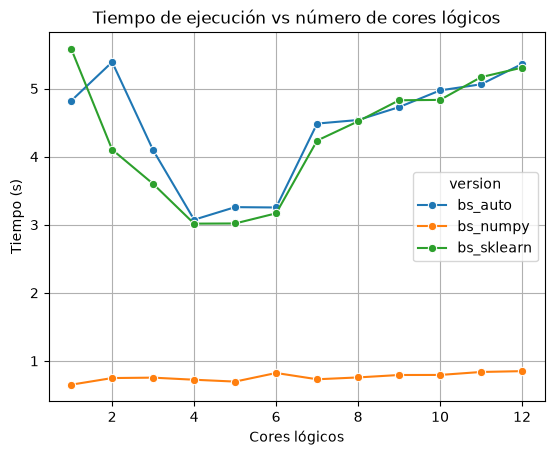

In [ ]:
ax = sns.lineplot(data=df, x="p", y="tiempo", hue="version", marker="o")
ax.set_title("Tiempo de ejecución vs número de cores lógicos")
ax.set_ylabel("Tiempo (s)")
ax.set_xlabel("Cores lógicos")
plt.grid(True)
plt.show()